# 1. 读取三例供者的单细胞数据

本轮使用CID4471、CID4067和CID4535。先从Wu全队列中按条码提取原始count，再分别计算每例的QC指标，查看各类细胞的分布。

原始对象由同目录的extract_er_qc_donors.py生成。CID4471和CID4535为ILC，CID4067为IDC，临床表中三例均标记为Naïve。

In [1]:
from pathlib import Path
import json
import sys

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from IPython.display import display

project_dir = Path("/Users/georicl/Documents/sc_sncell_github")
object_dir = project_dir / "data/processed/Wu2021_ER_donor_qc_v1"
result_dir = project_dir / "results/Wu2021_ER_donor_qc_v1"
donors = ["CID4471", "CID4067", "CID4535"]
result_dir.mkdir(parents=True, exist_ok=True)

# 第一次运行时先提取三例，已有对象直接读取
if not all((object_dir / f"{donor}_counts_before_qc.h5ad").exists() for donor in donors):
    sys.path.insert(0, str(project_dir / "src/sc_sncell_github"))
    from extract_er_qc_donors import extract_donors
    extract_donors()

objects = {
    donor: ad.read_h5ad(object_dir / f"{donor}_counts_before_qc.h5ad")
    for donor in donors
}
for donor, a in objects.items():
    print(donor, a.shape)


CID4471 (8609, 29733)
CID4067 (3764, 29733)
CID4535 (3961, 29733)


# 2. 重新计算QC指标并核对metadata

在原始count中标记MT-开头的基因，计算每个细胞的UMI数、检测基因数和线粒体占比，再与作者metadata中的对应字段逐细胞比较。

参考标签沿用前面的规则，T-cells展开为作者minor标签，其他细胞使用major标签。

In [2]:
qc_tables = []
checks = []
for donor, a in objects.items():
    a.var["mt"] = a.var["gene_symbol"].str.startswith("MT-").to_numpy()
    total = np.asarray(a.X.sum(axis=1)).ravel()
    n_genes = np.asarray((a.X > 0).sum(axis=1)).ravel()
    mt_counts = np.asarray(a.X[:, a.var["mt"].to_numpy()].sum(axis=1)).ravel()
    pct_mt = np.divide(mt_counts * 100, total, out=np.zeros(len(total), dtype=float), where=total > 0)
    a.obs["total_counts"] = total
    a.obs["n_genes_by_counts"] = n_genes
    a.obs["pct_counts_mt"] = pct_mt
    a.obs["reference_label"] = a.obs["celltype_major"].astype("string")
    is_t = a.obs["celltype_major"].eq("T-cells")
    a.obs.loc[is_t, "reference_label"] = a.obs.loc[is_t, "celltype_minor"].astype("string")
    a.obs["reference_label"] = a.obs["reference_label"].astype("category")
    np.testing.assert_array_equal(total, a.obs["nCount_RNA"])
    np.testing.assert_array_equal(n_genes, a.obs["nFeature_RNA"])
    checks.append({
        "donor_id": donor,
        "umi_mismatch": int((total != a.obs["nCount_RNA"]).sum()),
        "gene_count_mismatch": int((n_genes != a.obs["nFeature_RNA"]).sum()),
        "max_mt_difference": float(np.max(np.abs(pct_mt - a.obs["percent.mito"]))),
        "n_mt_genes": int(a.var["mt"].sum()),
    })
    table = a.obs.copy()
    table["donor_id"] = donor
    qc_tables.append(table)

qc = pd.concat(qc_tables)
qc.index.name = "barcode"
check_table = pd.DataFrame(checks)
display(check_table)
metrics = ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
quantiles = qc.groupby("donor_id")[metrics].quantile([0, 0.01, 0.05, 0.5, 0.95, 0.99, 1])
display(quantiles)
check_table.to_csv(result_dir / "metadata_alignment_checks.csv", index=False)
quantiles.to_csv(result_dir / "qc_quantiles.csv")


,donor_id,umi_mismatch,gene_count_mismatch,max_mt_difference,n_mt_genes
0,CID4471,0,0,5.151435e-14,13
1,CID4067,0,0,5.151435e-14,13
2,CID4535,0,0,5.329071e-14,13


total_counts  n_genes_by_counts  pct_counts_mt
donor_id                                                     
CID4067  0.00        296.00             207.00       0.093545
         0.01        530.63             314.63       1.055982
         0.05        781.15             431.30       1.870818
         0.50       3011.00            1329.50       7.566265
         0.95       9827.25            2943.95      16.959539
         0.99      14315.81            3740.44      19.337045
         1.00      28398.00            5446.00      19.989282
CID4471  0.00        295.00             228.00       0.102987
         0.01        997.00             578.08       1.708716
         0.05       1758.00             867.00       4.054973
         0.50       5041.00            1842.00       7.747057
         0.95      19255.20            4284.60      14.661265
         0.99      34031.24            5670.72      18.381809
         1.00      70520.00            7480.00      19.950453
CID4535  0.00        261.00             201.00       0.429448
         0.01        307.60             220.00       0.870904
         0.05        740.00             399.00       1.634043
         0.50       8818.00            2329.00       6.970245
         0.95      37565.00            5284.00      16.645525
         0.99      53396.80            6282.20      18.917850
         1.00     112916.00            7887.00      19.982602

# 3. 查看每例供者和细胞类型的QC分布

UMI和检测基因数跨度较大，前两张图使用log10刻度。线粒体比例按百分数展示。再按参考标签汇总每类的中位数，观察低计数是否集中在特定细胞群。

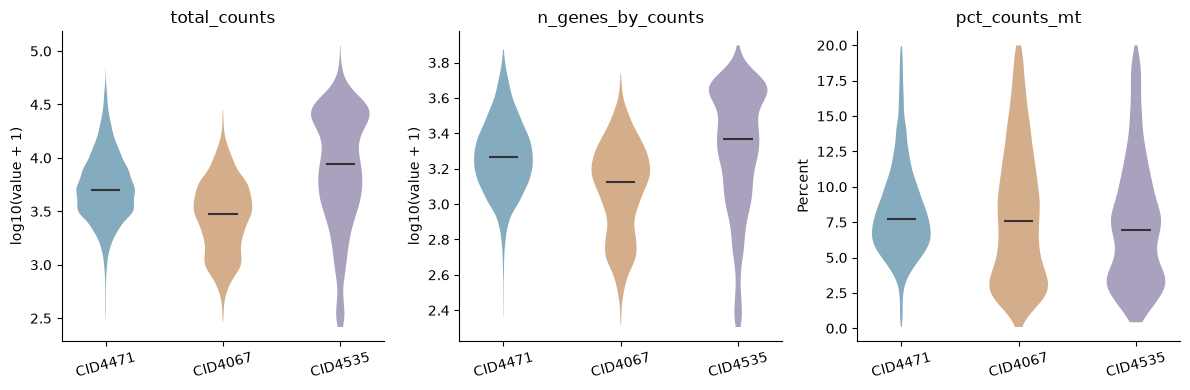

n_cells  umi_median  genes_median  mt_median  \
donor_id reference_label                                                   
CID4067  B-cells                 53       983.0         473.0   4.138245   
         CAFs                   135      3975.0        1609.0   2.771937   
         Cancer Epithelial     2352      3925.0        1640.0  10.198233   
         Cycling T-cells          6      1419.5         738.0   2.840572   
         Endothelial            186      1529.0         806.0   3.708723   
         Myeloid                266      3498.5        1269.5   3.106413   
         NK cells                48      1021.0         540.5   3.354177   
         NKT cells               39      1183.0         598.0   3.005686   
         PVL                     83      1419.0         709.0   4.825684   
         T cells CD4+           353      1132.0         535.0   3.074558   
         T cells CD8+           243       983.0         520.0   3.274559   
CID4471  B-cells                 99      2752.0        1036.0   9.024012   
         CAFs                  1292      4607.5        1767.5   6.885256   
         Cancer Epithelial      212     10768.0        2992.5  11.976826   
         Cycling T-cells          8      1677.0         961.0   6.237593   
         Endothelial           2778      6115.5        2141.0   7.184958   
         Myeloid                285      5724.0        1836.0   6.955756   
         NK cells                30      2080.5         914.5   8.322706   
         NKT cells               32      2329.5        1116.5   6.568117   
         Normal Epithelial     1966      6460.0        2207.5   8.909645   
         PVL                   1285      3865.0        1495.0   8.093126   
         Plasmablasts            51     12859.0        1785.0   3.220065   
         T cells CD4+           412      2663.0        1024.5   6.934132   
         T cells CD8+           159      2169.0         979.0   7.329843   
CID4535  B-cells                 56      1406.0         685.0   4.321225   
         CAFs                   102      4467.0        1569.5   3.926973   
         Cancer Epithelial     2223     20028.0        3827.0   8.703199   
         Cycling T-cells         19      3686.0        1477.0   3.403489   
         Endothelial            219      4936.0        1950.0   3.831194   
         Myeloid                255      8215.0        2051.0   4.819277   
         NK cells                25      2710.0         996.0   3.448276   
         NKT cells               15      2676.0        1067.0   3.720372   
         Normal Epithelial       22     15872.5        3417.5   4.858464   
         PVL                    592      5185.0        1793.5   3.880385   
         Plasmablasts            96     16254.0        1892.0   1.737904   
         T cells CD4+           239       584.0         343.0   5.128205   
         T cells CD8+            98      2878.0        1095.5   3.718980   

                               mt_max  
donor_id reference_label               
CID4067  B-cells             8.556701  
         CAFs               12.226067  
         Cancer Epithelial  19.989282  
         Cycling T-cells     4.281537  
         Endothelial        18.843844  
         Myeloid            15.876777  
         NK cells           13.767519  
         NKT cells           5.417607  
         PVL                19.700748  
         T cells CD4+       14.805825  
         T cells CD8+       13.353116  
CID4471  B-cells            19.076678  
         CAFs               19.805589  
         Cancer Epithelial  19.871452  
         Cycling T-cells    16.281063  
         Endothelial        19.924635  
         Myeloid            17.521873  
         NK cells           16.522491  
         NKT cells          13.893805  
         Normal Epithelial  19.950453  
         PVL                19.902405  
         Plasmablasts        9.922225  
         T cells CD4+       18.078382  
         T cells CD8+       12.721490  
CID4535  B-cells       

In [3]:
colors = ["#427f9b", "#bd824b", "#7d6f9b"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric in zip(axes, metrics):
    values = [qc.loc[qc.donor_id.eq(d), metric].to_numpy() for d in donors]
    if metric != "pct_counts_mt":
        values = [np.log10(v + 1) for v in values]
    parts = ax.violinplot(values, showmedians=True, showextrema=False)
    for body, color in zip(parts["bodies"], colors):
        body.set_facecolor(color)
        body.set_alpha(0.65)
    parts["cmedians"].set_color("#333333")
    ax.set_xticks([1, 2, 3], donors, rotation=15)
    ax.set_ylabel("Percent" if metric == "pct_counts_mt" else "log10(value + 1)")
    ax.set_title(metric)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(result_dir / "donor_qc_distributions.png", dpi=300)
fig.savefig(result_dir / "donor_qc_distributions.pdf")
plt.show()

by_type = qc.groupby(["donor_id", "reference_label"], observed=True).agg(
    n_cells=("total_counts", "size"),
    umi_median=("total_counts", "median"),
    genes_median=("n_genes_by_counts", "median"),
    mt_median=("pct_counts_mt", "median"),
    mt_max=("pct_counts_mt", "max"),
)
display(by_type)
by_type.to_csv(result_dir / "qc_by_reference_type.csv")


# 4. 标记分布较极端和谱系marker共同表达的细胞

在每个供者的同一参考类型内，对log1p UMI、log1p检测基因数和线粒体比例计算中位数与MAD。超过中位数上下5倍MAD的计数，以及高于中位数5倍MAD的线粒体比例，记录为待查看项。每组至少20个细胞且MAD大于0时计算。

另外查看上皮与T细胞marker，以及CAF与PVL marker的共同表达。每个面板至少2个基因达到2 UMI时记为该面板表达，两个面板同时满足时标记共同表达。每项标记都写入逐细胞记录，结合作者标签和QC指标一起查看。

In [4]:
mad_flags = {
    "review_low_umi": ("total_counts", "low"),
    "review_high_umi": ("total_counts", "high"),
    "review_low_genes": ("n_genes_by_counts", "low"),
    "review_high_genes": ("n_genes_by_counts", "high"),
    "review_high_mt": ("pct_counts_mt", "high"),
}
threshold_rows = []
for flag in mad_flags:
    qc[flag] = False
for (donor, label), group in qc.groupby(["donor_id", "reference_label"], observed=True):
    for flag, (metric, direction) in mad_flags.items():
        values = group[metric].to_numpy(dtype=float)
        if metric != "pct_counts_mt":
            values = np.log1p(values)
        center = float(np.median(values))
        mad = float(np.median(np.abs(values - center)))
        eligible = len(group) >= 20 and mad > 0
        threshold = center + (5 if direction == "high" else -5) * mad
        hits = (values > threshold if direction == "high" else values < threshold) if eligible else np.zeros(len(group), dtype=bool)
        qc.loc[group.index, flag] = hits
        threshold_rows.append({
            "donor_id": donor, "reference_label": label, "flag": flag,
            "n_cells": len(group), "median": center, "mad": mad,
            "threshold_transformed": threshold, "applied": eligible,
        })

panels = {
    "epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "T_lineage": ["CD3D", "CD3E", "TRAC"],
    "CAF": ["COL1A1", "COL1A2", "DCN", "LUM"],
    "PVL": ["RGS5", "CSPG4", "MCAM"],
}
marker_genes = list(dict.fromkeys(sum(panels.values(), []) + ["CD8A", "CD8B", "NKG7", "GNLY", "PECAM1", "VWF"]))
expression_tables = []
for donor, a in objects.items():
    assert set(marker_genes).issubset(a.var_names)
    marker_counts = pd.DataFrame(a[:, marker_genes].X.toarray(), index=a.obs_names, columns=marker_genes)
    expression = np.log1p(marker_counts.div(a.obs["total_counts"], axis=0) * 10000)
    expression_tables.append(expression)
    for panel, genes in panels.items():
        qc.loc[a.obs_names, f"{panel}_n_markers_ge2"] = marker_counts[genes].ge(2).sum(axis=1)
qc["review_epithelial_T"] = qc["epithelial_n_markers_ge2"].ge(2) & qc["T_lineage_n_markers_ge2"].ge(2)
qc["review_CAF_PVL"] = qc["CAF_n_markers_ge2"].ge(2) & qc["PVL_n_markers_ge2"].ge(2)
review_columns = list(mad_flags) + ["review_epithelial_T", "review_CAF_PVL"]
qc["review_any"] = qc[review_columns].any(axis=1)
review_summary = qc.groupby("donor_id")[review_columns + ["review_any"]].sum()
display(review_summary)
pd.DataFrame(threshold_rows).to_csv(result_dir / "review_thresholds.csv", index=False)
review_summary.to_csv(result_dir / "review_flag_counts.csv")
qc.loc[qc.review_any].to_csv(result_dir / "cells_for_review.csv")


,review_low_umi,review_high_umi,review_low_genes,review_high_genes,review_high_mt,review_epithelial_T,review_CAF_PVL,review_any
donor_id,,,,,,,,
CID4067,11,1,13,3,52,0,8,71
CID4471,33,9,38,7,159,1,98,301
CID4535,195,1,313,1,148,6,87,540


# 5. 按作者标签查看marker表达

先按每细胞10000进行归一化并log1p转换，再计算每类细胞的marker平均表达。热图颜色在每个基因内按三例全部参考群的最大值缩放，便于查看该基因主要在哪些群表达。

对应的平均表达和检测比例分别保存，原始counts保留在供者对象中。热图中的白色行表示该供者没有这一参考类型的细胞。

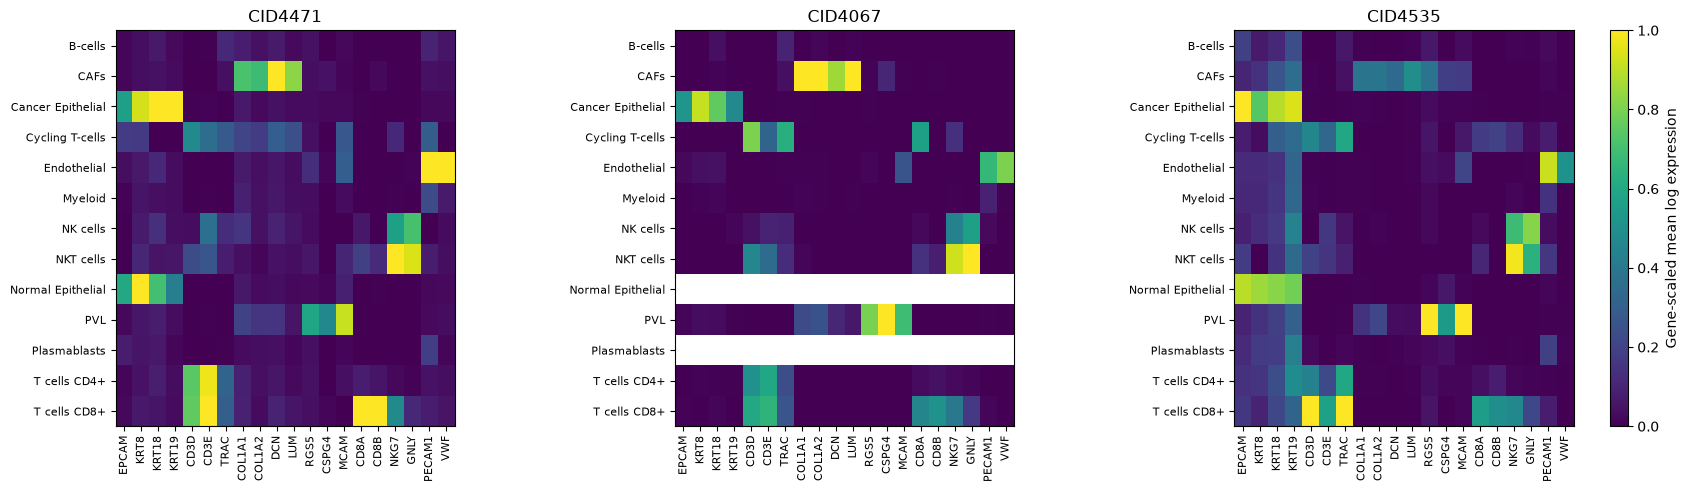

In [5]:
expression = pd.concat(expression_tables).loc[qc.index]
group_keys = [qc["donor_id"], qc["reference_label"]]
mean_expression = expression.groupby(group_keys, observed=True).mean()
detection_fraction = expression.gt(0).groupby(group_keys, observed=True).mean()
mean_expression.to_csv(result_dir / "marker_mean_log_expression.csv")
detection_fraction.to_csv(result_dir / "marker_detection_fraction.csv")
scaled = mean_expression.div(mean_expression.max(axis=0).replace(0, 1), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
labels = sorted(qc["reference_label"].astype(str).unique())
for ax, donor in zip(axes, donors):
    values = scaled.loc[donor].reindex(labels)
    im = ax.imshow(values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set_yticks(range(len(labels)), labels, fontsize=8)
    ax.set_xticks(range(len(marker_genes)), marker_genes, rotation=90, fontsize=8)
    ax.set_title(donor)
fig.subplots_adjust(left=0.12, right=0.93, bottom=0.22, wspace=0.65)
bar_ax = fig.add_axes([0.95, 0.22, 0.01, 0.66])
fig.colorbar(im, cax=bar_ax, label="Gene-scaled mean log expression")
fig.savefig(result_dir / "marker_expression_by_donor.png", dpi=300)
fig.savefig(result_dir / "marker_expression_by_donor.pdf")
plt.show()


# 6. 保存QC对象和处理前后数量

本轮沿用作者保留的细胞，检查计数有效且UMI大于0。每个供者保留至少在1个细胞中表达的基因，分布和共同表达标记保存在obs中。

将处理前后各参考类型的数量并列保存，同时记录每例保留的基因数。后续参考供者与测试供者的用途表使用这些数量。

In [6]:
qc["qc_keep"] = (
    np.isfinite(qc["total_counts"]) & qc["total_counts"].gt(0)
    & np.isfinite(qc["pct_counts_mt"]) & qc["n_genes_by_counts"].gt(0)
)
qc["filter_reason"] = np.where(qc["qc_keep"], "", "nonfinite_or_empty_counts")
comparison_rows = []
donor_rows = []
for donor, a in objects.items():
    records = qc.loc[a.obs_names]
    for column in records.columns:
        a.obs[column] = records[column]
    keep_cells = a.obs["qc_keep"].to_numpy()
    keep_genes = np.asarray((a.X[keep_cells] > 0).sum(axis=0)).ravel() >= 1
    a_qc = a[keep_cells, keep_genes].copy()
    a_qc.uns["qc_parameters_json"] = json.dumps({
        "cell_policy": "retain author cells with finite positive counts",
        "min_cells_per_gene": 1, "review_mad_multiplier": 5,
        "review_min_group_cells": 20, "panel_min_umi": 2, "panel_min_genes": 2,
    })
    a_qc.write_h5ad(object_dir / f"{donor}_counts_after_qc.h5ad", compression="gzip")
    before = a.obs["reference_label"].value_counts()
    after = a_qc.obs["reference_label"].value_counts()
    for label in labels:
        nb, na = int(before.get(label, 0)), int(after.get(label, 0))
        comparison_rows.append({
            "donor_id": donor, "subtype": str(a.obs["subtype"].iloc[0]),
            "reference_label": label, "before_qc": nb, "after_qc": na, "excluded": nb - na,
        })
    donor_rows.append({
        "donor_id": donor, "before_cells": a.n_obs, "after_cells": a_qc.n_obs,
        "before_genes": a.n_vars, "after_genes": a_qc.n_vars,
        "review_cells": int(a.obs["review_any"].sum()),
    })
comparison = pd.DataFrame(comparison_rows)
donor_summary = pd.DataFrame(donor_rows)
display(donor_summary)
display(comparison)
comparison.to_csv(result_dir / "donor_reference_counts_before_after_qc.csv", index=False)
donor_summary.to_csv(result_dir / "donor_qc_summary.csv", index=False)
qc.to_csv(result_dir / "cell_qc_records.csv")
after_counts = comparison.pivot(index="donor_id", columns="reference_label", values="after_qc")
after_counts.to_csv(result_dir / "donor_by_reference_after_qc.csv")
params = {
    "donors": donors,
    "source_matrix": "data/raw/wu2021_scrna/Wu_etal_2021_BRCA_scRNASeq/count_matrix_sparse.mtx",
    "cell_policy": "retain author cells with finite positive counts",
    "min_cells_per_gene": 1, "review_mad_multiplier": 5, "review_min_group_cells": 20,
    "panel_min_umi": 2, "panel_min_genes": 2, "panels": panels,
}
(result_dir / "parameters.json").write_text(json.dumps(params, ensure_ascii=False, indent=2), encoding="utf-8")
# 保存按类型的复核标记，并更新供者用途表中的QC进度
qc.groupby(["donor_id", "reference_label"], observed=True)[review_columns + ["review_any"]].sum().to_csv(result_dir / "review_flags_by_reference_type.csv")
plan = pd.read_csv(project_dir / "results/Wu2021_ER_donor_plan/er_donor_inclusion_and_role.csv")
plan_after_qc = plan.merge(donor_summary, on="donor_id", how="left", validate="one_to_one")
plan_after_qc.loc[plan_after_qc.donor_id.isin(donors), "qc_status"] = "已完成本轮QC；保留作者细胞，记录分布与共表达标记"
plan_after_qc.to_csv(result_dir / "er_donor_plan_after_qc.csv", index=False)
print("对象目录：", object_dir)
print("结果目录：", result_dir)


,donor_id,before_cells,after_cells,before_genes,after_genes,review_cells
0,CID4471,8609,8609,29733,24528,301
1,CID4067,3764,3764,29733,21512,71
2,CID4535,3961,3961,29733,22061,540


,donor_id,subtype,reference_label,before_qc,after_qc,excluded
0,CID4471,ER+,B-cells,99,99,0
1,CID4471,ER+,CAFs,1292,1292,0
2,CID4471,ER+,Cancer Epithelial,212,212,0
3,CID4471,ER+,Cycling T-cells,8,8,0
4,CID4471,ER+,Endothelial,2778,2778,0
5,CID4471,ER+,Myeloid,285,285,0
6,CID4471,ER+,NK cells,30,30,0
7,CID4471,ER+,NKT cells,32,32,0
8,CID4471,ER+,Normal Epithelial,1966,1966,0
9,CID4471,ER+,PVL,1285,1285,0


对象目录： /Users/georicl/Documents/sc_sncell_github/data/processed/Wu2021_ER_donor_qc_v1
结果目录： /Users/georicl/Documents/sc_sncell_github/results/Wu2021_ER_donor_qc_v1
